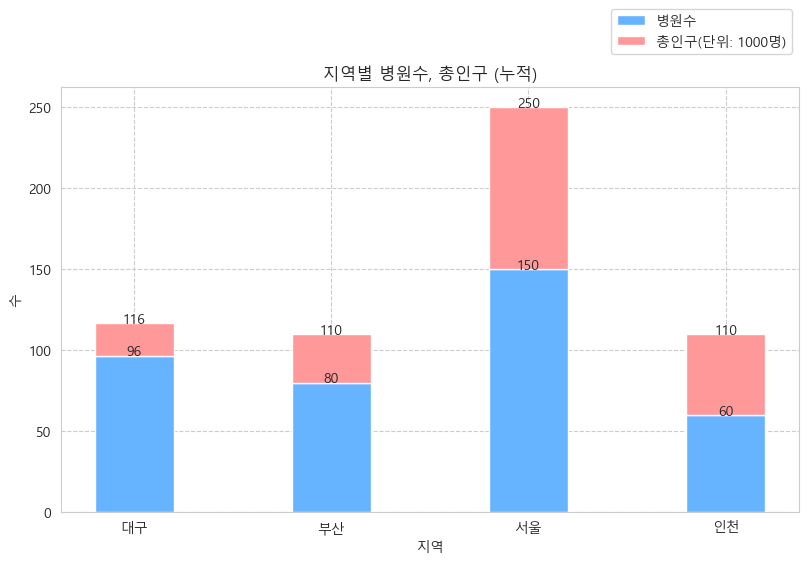

In [35]:

# 반드시 pandas는 import하여 사용
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 병합 (지역 기준)
merged = pd.merge(df1, df2, on="지역", how="outer")

# 결측치 처리
# 총인구 없는 값 -> 평균으로 채우기
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 결과 확인
merged
sns.set_style('whitegrid')
sns.set_palette('pastel')
# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(8, 5))

# -------------------------------------------
# 병원수 그래프
plt.bar(merged["지역"], merged["병원수"], label="병원수", color='#66b3ff', width=0.4,)
# 인구수(축소) 그래프
plt.bar(
    merged["지역"],
    merged["총인구"] / 10000,
    bottom=merged["병원수"],
    label="총인구(단위: 1000명)",
    color='#ff9999',
    width=0.4,
)

# -------------------------------------------
# 값 표시
for i in range(len(merged)):
    plt.text(
        i,
        merged['병원수'][i],
        int(merged['병원수'][i]),
        ha='center'
    )
for i in range(len(merged)):
    total = merged['병원수'][i] + merged['총인구'][i] / 10000
    plt.text(
        i,
        total,
        int(total),
        ha='center'
    )

plt.title("지역별 병원수, 총인구 (누적)")
plt.tight_layout()
plt.xlabel("지역")
plt.ylabel("수")
plt.grid(linestyle='--')
# 범례 생성
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1, 1.2),
    # ncol=2
)

plt.show()
